# 集成学习实战：决策树 / 随机森林 / AdaBoost / GBDT / CatBoost

**任务**：根据乘客信息（性别、年龄、舱位、票价等），预测其是否在沉船事故中**幸存**（二分类）
**核心目标**：通过同一份数据，横向对比决策树 / 随机森林 / AdaBoost / GBDT / CatBoost 五种算法，掌握从单模型到集成学习的演进思路。

## 🚀 建模流程（步骤）

1. **环境配置**
2. **数据加载与概览**：train(891) / test(418)，字段含义、缺失值统计
3. **探索性数据分析EDA**：幸存率与性别、舱位、年龄、票价的关系
4. **数据清洗**：Age / Embarked / Cabin 缺失值处理
5. **特征工程**：提取 Title（称呼）、FamilySize、票价分桶等
6. **建模对比**：5 个模型统一 Pipeline + 5 折交叉验证
7. **评估对比**：准确率 + 混淆矩阵 + ROC-AUC，输出对比表
8. **预测提交**：生成 `submission.csv`，回填到 `data/` 目录


## 1. 环境配置


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("环境配置完成")
print(f"当前工作目录: {os.getcwd()}")


环境配置完成
当前工作目录: e:\BaiduNetdiskDownload\Study_files\学习考证\Agent_Exercise\Kaggle_Competitions\Machine_learning\DT_RF_AdaBoost_GBDT_CatBoost


In [ ]:
DATA_DIR = "Titanic-data" if os.path.exists("Titanic-data") else os.path.join("DT_RF_AdaBoost_GBDT_CatBoost", "Titanic-data")
assert os.path.exists(DATA_DIR), f"数据目录不存在: {DATA_DIR}"
print("数据文件:", sorted(os.listdir(DATA_DIR)))


数据文件: ['gender_submission.csv', 'test.csv', 'train.csv']


## 2. 数据加载与概览


In [23]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
gender_sample = pd.read_csv(os.path.join(DATA_DIR, "gender_submission.csv"))

print(f"训练集形状: {train.shape}")
print(f"测试集形状: {test.shape}")
print(f"提交样例形状: {gender_sample.shape}")

test_ids = test["PassengerId"].copy()
train.head()


训练集形状: (891, 12)
测试集形状: (418, 11)
提交样例形状: (418, 2)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0000,0,0,373450,8.0500,NaN,S


In [24]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 3. 探索性数据分析（EDA）


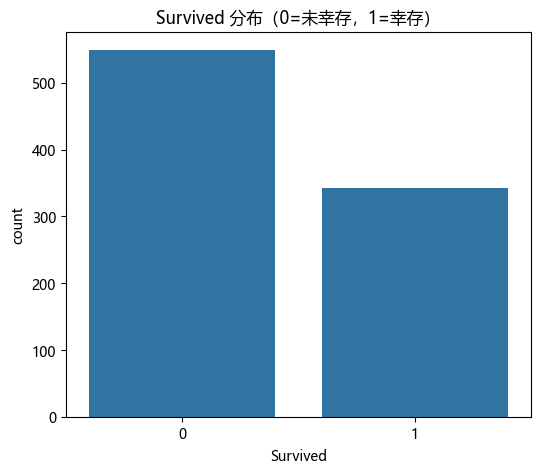

幸存率: 38.38%


In [25]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
target_col = "Survived"
plt.figure(figsize=(6, 5))
sns.countplot(data=train, x=target_col)
plt.title("Survived 分布（0=未幸存，1=幸存）")
plt.show()
print(f"幸存率: {train[target_col].mean():.2%}")


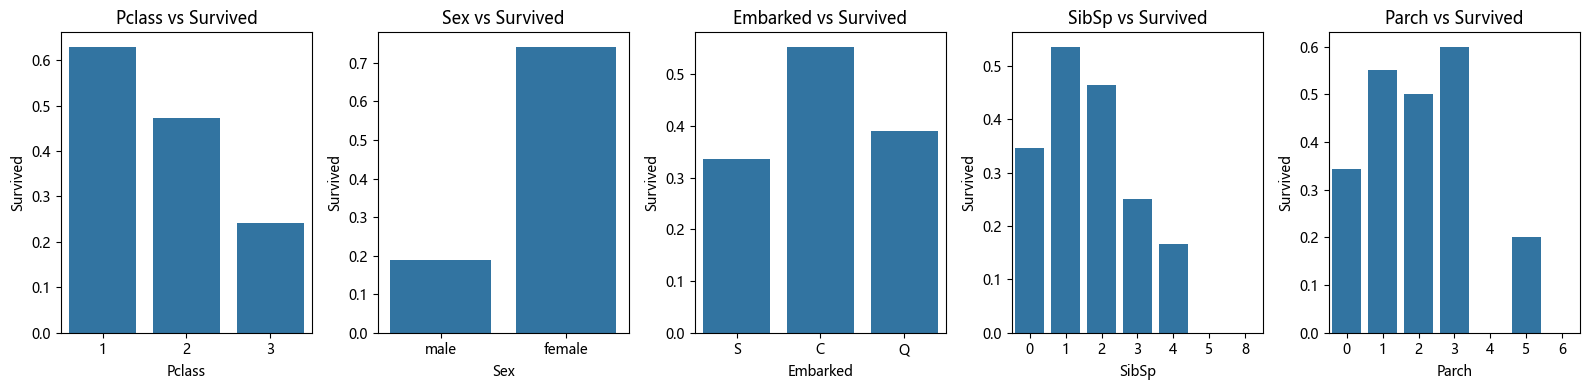

In [26]:
key_feats = ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]
fig, axes = plt.subplots(1, len(key_feats), figsize=(16, 4))
for i, f in enumerate(key_feats):
    sns.barplot(data=train, x=f, y=target_col, ax=axes[i], errorbar=None)
    axes[i].set_title(f"{f} vs {target_col}")
plt.tight_layout()
plt.show()


In [27]:
num_feats = ["Age", "Fare", "SibSp", "Parch"]
train[num_feats].describe()


,Age,Fare,SibSp,Parch
count,714.0000,891.0000,891.0000,891.0000
mean,29.6991,32.2042,0.5230,0.3816
std,14.5265,49.6934,1.1027,0.8061
min,0.4200,0.0000,0.0000,0.0000
25%,20.1250,7.9104,0.0000,0.0000
50%,28.0000,14.4542,0.0000,0.0000
75%,38.0000,31.0000,1.0000,0.0000
max,80.0000,512.3292,8.0000,6.0000


In [28]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_pct = (missing_train / len(train) * 100).round(2)
pd.DataFrame({"缺失数量": missing_train, "缺失比例%": missing_pct})


,缺失数量,缺失比例%
Cabin,687,77.1000
Age,177,19.8700
Embarked,2,0.2200


## 4. 数据清洗


In [29]:
def clean(df):
    df = df.copy()
    df = df.drop(columns=["Cabin"], errors="ignore")
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())
    return df

train_clean = clean(train)
test_clean = clean(test)

print(f"清洗后训练集: {train_clean.shape}")
print(f"清洗后测试集: {test_clean.shape}")
print("清洗后缺失值:", int(train_clean.isnull().sum().sum()))


清洗后训练集: (891, 11)
清洗后测试集: (418, 10)
清洗后缺失值: 0


## 5. 特征工程


In [30]:
def feature_engineering(df, fare_edges=None):
    df = df.copy()
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    df["Title"] = df["Title"].replace(
        ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"], "Rare")
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    if fare_edges is not None:
        df["FareBin"] = pd.cut(df["Fare"], bins=fare_edges, labels=False, include_lowest=True)
    else:
        df["FareBin"] = pd.qcut(df["Fare"], q=4, labels=False, duplicates="drop")
    df["AgeBin"] = pd.cut(df["Age"], bins=[0, 12, 20, 40, 60, 120], labels=False)
    df = df.drop(columns=["PassengerId", "Name", "Ticket"], errors="ignore")
    return df

_, fare_edges = pd.qcut(train_clean["Fare"], q=4, retbins=True)
train_feat = feature_engineering(train_clean, fare_edges=fare_edges)
test_feat = feature_engineering(test_clean, fare_edges=fare_edges)

print(f"特征工程后训练集: {train_feat.shape}")
print(f"特征工程后测试集: {test_feat.shape}")
train_feat.head()


特征工程后训练集: (891, 13)
特征工程后测试集: (418, 12)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,FareBin,AgeBin
0,0,3,male,22.0000,1,0,7.2500,S,Mr,2,0,0,2
1,1,1,female,38.0000,1,0,71.2833,C,Mrs,2,0,3,2
2,1,3,female,26.0000,0,0,7.9250,S,Miss,1,1,1,2
3,1,1,female,35.0000,1,0,53.1000,S,Mrs,2,0,3,2
4,0,3,male,35.0000,0,0,8.0500,S,Mr,1,1,1,2


## 6. 模型对比（决策树 / 随机森林 / AdaBoost / GBDT / CatBoost）


In [31]:
X = train_feat.drop(columns=[target_col])
y = train_feat[target_col]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}")
print(f"训练集幸存率: {y_train.mean():.2%}")

models = {
    "决策树": DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE),
    "随机森林": RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "GBDT": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(iterations=200, learning_rate=0.05, depth=4, verbose=0, random_seed=RANDOM_STATE, allow_writing_files=False),
}


训练集: (712, 12), 验证集: (179, 12)
训练集幸存率: 38.34%


In [32]:
results = {}
for name, clf in models.items():
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf),
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    results[name] = {"准确率": acc, "AUC": auc, "模型": model}
    print(f"{name:6s}  准确率={acc:.4f}  AUC={auc:.4f}")


决策树     准确率=0.7877  AUC=0.8375
随机森林    准确率=0.8380  AUC=0.8516
AdaBoost  准确率=0.8045  AUC=0.8454
GBDT    准确率=0.8156  AUC=0.8516
CatBoost  准确率=0.8268  AUC=0.8590


In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, clf in models.items():
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf),
    ])
    cv_acc = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    cv_auc = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
    cv_results[name] = {"CV准确率": cv_acc.mean(), "CV-AUC": cv_auc.mean()}
    print(f"{name:6s}  CV准确率={cv_acc.mean():.4f}  CV-AUC={cv_auc.mean():.4f}")


决策树     CV准确率=0.8283  CV-AUC=0.8533
随机森林    CV准确率=0.8316  CV-AUC=0.8722
AdaBoost  CV准确率=0.8137  CV-AUC=0.8667
GBDT    CV准确率=0.8361  CV-AUC=0.8770
CatBoost  CV准确率=0.8395  CV-AUC=0.8811


In [34]:
comparison = pd.DataFrame(
    {
        "验证集准确率": [results[k]["准确率"] for k in models],
        "验证集AUC": [results[k]["AUC"] for k in models],
        "5折CV准确率": [cv_results[k]["CV准确率"] for k in models],
        "5折CV-AUC": [cv_results[k]["CV-AUC"] for k in models],
    },
    index=models.keys(),
).round(4).sort_values("5折CV-AUC", ascending=False)
comparison


,验证集准确率,验证集AUC,5折CV准确率,5折CV-AUC
CatBoost,0.8268,0.8590,0.8395,0.8811
GBDT,0.8156,0.8516,0.8361,0.8770
随机森林,0.8380,0.8516,0.8316,0.8722
AdaBoost,0.8045,0.8454,0.8137,0.8667
决策树,0.7877,0.8375,0.8283,0.8533


## 7. 模型评估与对比


最佳模型: CatBoost（按 5 折 CV-AUC 排序）


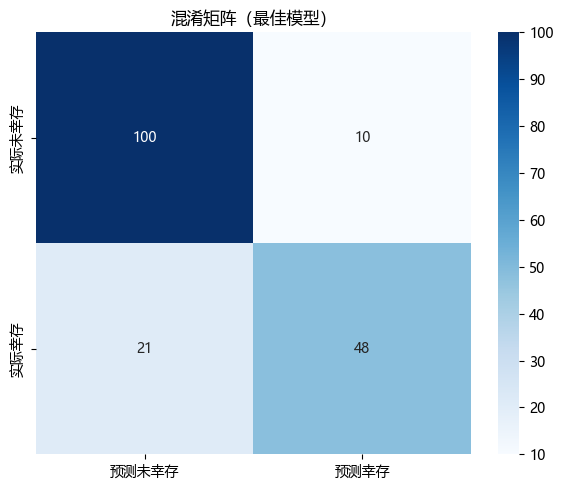

              precision    recall  f1-score   support

         未幸存       0.83      0.91      0.87       110
          幸存       0.83      0.70      0.76        69

    accuracy                           0.83       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179



In [35]:
best_name = max(cv_results, key=lambda k: cv_results[k]["CV-AUC"])
best_model = results[best_name]["模型"]

y_pred = best_model.predict(X_val)
print(f"最佳模型: {best_name}（按 5 折 CV-AUC 排序）")

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_val, y_pred), annot=True, fmt="d", cmap="Blues",
    xticklabels=["预测未幸存", "预测幸存"],
    yticklabels=["实际未幸存", "实际幸存"],
)
plt.title("混淆矩阵（最佳模型）")
plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred, target_names=["未幸存", "幸存"]))


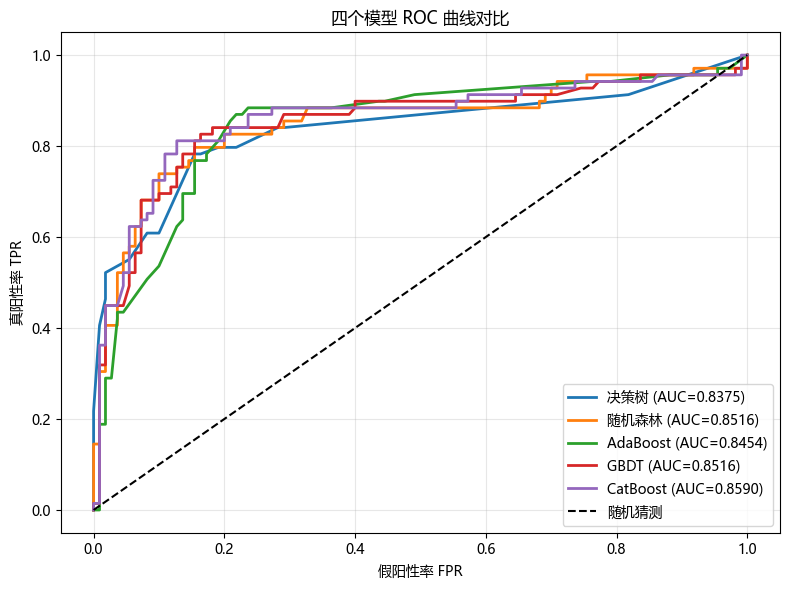

In [36]:
plt.figure(figsize=(8, 6))
for name in models:
    proba = results[name]["模型"].predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_val = roc_auc_score(y_val, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="随机猜测")
plt.xlabel("假阳性率 FPR")
plt.ylabel("真阳性率 TPR")
plt.title("四个模型 ROC 曲线对比")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


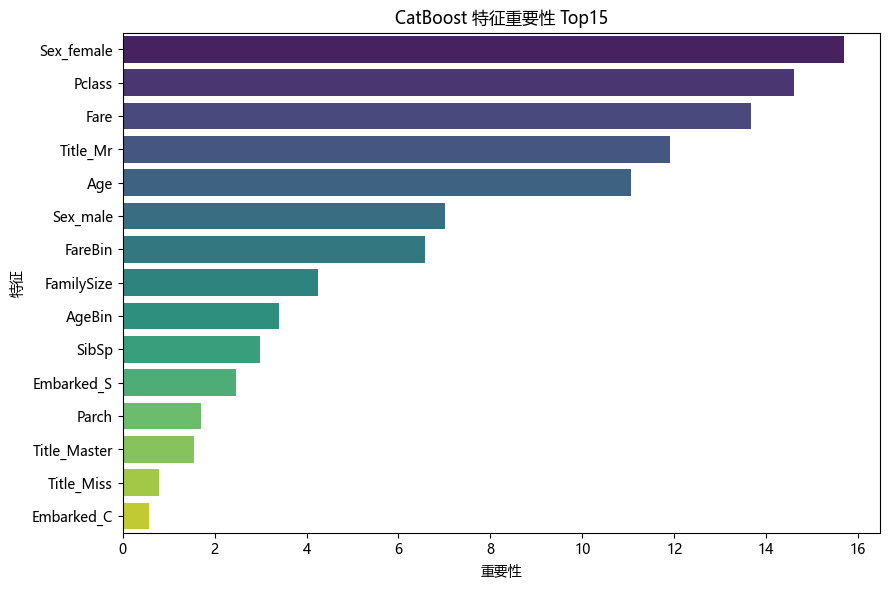

In [37]:
clf = best_model.named_steps["classifier"]
cat_enc = best_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_names = list(num_features) + list(cat_enc.get_feature_names_out(cat_features))
imp_df = pd.DataFrame({"特征": encoded_names, "重要性": clf.feature_importances_})
imp_df = imp_df.sort_values("重要性", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, x="重要性", y="特征", palette="viridis")
plt.title(f"{best_name} 特征重要性 Top15")
plt.tight_layout()
plt.show()


## 8. 预测并生成提交文件


In [38]:
test_pred = best_model.predict(test_feat)
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": test_pred,
})
submission.head()


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [39]:
submission_path = os.path.join(DATA_DIR, "submission.csv")
submission.to_csv(submission_path, index=False)
print(f"已保存提交文件: {submission_path}")
print(f"提交行数: {len(submission)}（应与 gender_submission 一致 = {len(gender_sample)}）")


已保存提交文件: Titanic-data\submission.csv
提交行数: 418（应与 gender_submission 一致 = 418）


In [40]:
print("=" * 60)
print("Titanic 集成学习项目完成！")
print("=" * 60)
print(f"  最佳模型      : {best_name}")
print(f"  5折CV准确率   : {cv_results[best_name]['CV准确率']:.4f}")
print(f"  5折CV-AUC     : {cv_results[best_name]['CV-AUC']:.4f}")
print(f"  提交文件      : {submission_path}")
print("=" * 60)
print("\n结论要点：随机森林/GBDT 通过集成显著优于单棵决策树；")
print("AdaBoost 对小数据+噪声更敏感，参数需要更精细调优。")


Titanic 集成学习项目完成！
  最佳模型      : CatBoost
  5折CV准确率   : 0.8395
  5折CV-AUC     : 0.8811
  提交文件      : Titanic-data\submission.csv

结论要点：随机森林/GBDT 通过集成显著优于单棵决策树；
AdaBoost 对小数据+噪声更敏感，参数需要更精细调优。
